In [3]:
# this code was imported and edited from the below link:
# https://opencv.org/text-detection-and-removal-using-opencv/#h-text-detection-models-in-opencv

# the models used here can be found @ https://docs.opencv.org/4.13.0/d4/d43/tutorial_dnn_text_spotting.html

import cv2
import numpy as np
 
# Load the input image
# NOTE: the input image resolution is originally 3400 x 2200, but it needs to be lowered down to a 
# resolution of 3392 x 2176 since these CNNs need multiples of 32 to operate!! keep this in mind for
# using this in practice.
image_path = "file_io/page0.png"
image1 = cv2.imread(image_path)
image = cv2.resize(image1, (3392, 2176))
 
# Create copies for different models
annotated_image = image.copy()  
annotated_db50_image = image.copy()  
annotated_db18_image = image.copy()  
orig_image = image.copy()  # For inpainting (all models)
orig_db50_image = image.copy()  # For DB50
orig_db18_image = image.copy()  # For DB18
 
# Set input image size
inputSize = (3392, 2176)
 
# Load pre-trained models
textDetectorDB50 = cv2.dnn_TextDetectionModel_DB("file_io/DB_TD500_resnet50.onnx")
textDetectorDB18 = cv2.dnn_TextDetectionModel_DB("file_io/DB_TD500_resnet18.onnx")
 
# Set parameters for the models
conf_thresh = 0.8
nms_thresh = 0.4
bin_thresh = 0.3
poly_thresh = 0.5
mean = (122.67891434, 116.66876762, 104.00698793)
textDetectorDB18.setBinaryThreshold(bin_thresh).setPolygonThreshold(poly_thresh)
textDetectorDB18.setInputParams(1.0/255, inputSize, mean, True)
textDetectorDB50.setBinaryThreshold(bin_thresh).setPolygonThreshold(poly_thresh)
textDetectorDB50.setInputParams(1.0/255, inputSize, mean, True)
 
# Create inpainting masks
inpaint_mask = np.zeros(image.shape[:2], dtype=np.uint8)  # Mask for all models
inpaint_mask_db50 = np.zeros(image.shape[:2], dtype=np.uint8)  # Mask for DB50 only
inpaint_mask_db18 = np.zeros(image.shape[:2], dtype=np.uint8)  # Mask for DB18 only
 
# Detect text using the models
boxesDB18, _ = textDetectorDB18.detect(image)
boxesDB50, _ = textDetectorDB50.detect(image)
 
# Process all detected boxes
for box in boxesDB18 + boxesDB50:
    cv2.fillPoly(inpaint_mask, [np.array(box, np.int32)], 255)  # Full mask
    cv2.polylines(annotated_image, [np.array(box, np.int32)], isClosed=True, color=(0, 255, 0), thickness=1)  # Annotate all models (Green)
 
# Process DB50 detected boxes
for box in boxesDB50:
    cv2.fillPoly(inpaint_mask_db50, [np.array(box, np.int32)], 255)  # DB50 mask
    cv2.polylines(annotated_db50_image, [np.array(box, np.int32)], isClosed=True, color=(0, 0, 255), thickness=1)  # Annotate DB50 (Red)
 
# Process DB18 detected boxes
for box in boxesDB18:
    cv2.fillPoly(inpaint_mask_db18, [np.array(box, np.int32)], 255)  # DB18 mask
    cv2.polylines(annotated_db18_image, [np.array(box, np.int32)], isClosed=True, color=(255, 0, 0), thickness=1)  # Annotate DB18 (Blue)
 
# Perform inpainting
inpainted_image = cv2.inpaint(orig_image, inpaint_mask, inpaintRadius=5, flags=cv2.INPAINT_NS)  # All models
inpainted_db50_image = cv2.inpaint(orig_db50_image, inpaint_mask_db50, inpaintRadius=5, flags=cv2.INPAINT_NS)  # DB50 only
inpainted_db18_image = cv2.inpaint(orig_db18_image, inpaint_mask_db18, inpaintRadius=5, flags=cv2.INPAINT_NS)  # DB18 only
 
# Show results
# already have the .pngs posted, so this is commented out
# cv2.imshow('Original', image)
# cv2.imwrite('file_io/cv2_io/Annotated_AM.png', annotated_image)
# cv2.imwrite('file_io/cv2_io/Inpainted_AM.png', inpainted_image)
# cv2.imwrite('file_io/cv2_io/Annotated_DB50.png', annotated_db50_image)
# cv2.imwrite('file_io/cv2_io/Inpainted_DB50.png', inpainted_db50_image)
# cv2.imwrite('file_io/cv2_io/Annotated_DB18.png', annotated_db18_image)
# cv2.imwrite('file_io/cv2_io/Inpainted_DB18.png', inpainted_db18_image)

cv2.waitKey(0)
cv2.destroyAllWindows()

In [4]:
import sys
import numpy as np
import cv2

# Source - https://stackoverflow.com/q/56803000 (erosion)
# Source - https://stackoverflow.com/questions/45322630/how-to-detect-lines-in-opencv (line detection)

image_path = "file_io/cv2_io/Inpainted_AM.png"
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if image is None:
    raise FileNotFoundError(f"Check if the path '{image_path}' is correct.")

# first, convert gray lines to black to ensure full floorplan...
thresh_value = 248
max_value = 255
_, binary_img = cv2.threshold(image, thresh_value, max_value, cv2.THRESH_BINARY)

# ...then run erosion for easier line detection
### in the end product, erosion doesn't really benefit us... heavy lines end up muddying the image...

# (thresh, BlackWhite) = cv2.threshold(binary_img, thresh_value, max_value, cv2.THRESH_BINARY)
# kernel = np.ones((4, 4), np.uint8)
# erosion = cv2.erode(binary_img, kernel, iterations=1)
# cv2.imwrite('file_io/cv2_io/Erosion_2.png', erosion)

# lastly, run line detection and highlight detected lines
blur = cv2.GaussianBlur(binary_img, (5, 5), 0)
edges = cv2.Canny(blur, 50, 150, apertureSize=3)
lines = cv2.HoughLinesP(edges, 1, np.pi / 180, threshold=50, minLineLength=10, maxLineGap=10)

# create blank line_img to only see lines made by process
line_img = np.zeros_like(cv2.cvtColor(binary_img, cv2.COLOR_GRAY2BGR))
# line_img = cv2.cvtColor(erosion, cv2.COLOR_GRAY2BGR)
# line_img = cv2.cvtColor(binary_img, cv2.COLOR_GRAY2BGR)
if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        cv2.line(line_img, (x1, y1), (x2, y2), (0, 255, 0), 2)

line_img = cv2.resize(line_img, (848, 544), interpolation=cv2.INTER_AREA)
cv2.imwrite('file_io/cv2_io/Detected_Lines_noEro.png', line_img)

cv2.imshow('Detected Lines', line_img)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [5]:
# inside of OpenCV, images are stored as 3d arrays, with each pixel being stored as RGB info
# so, this can be interpreted as a navigatable matrix

np.set_printoptions(threshold=sys.maxsize)

with open('line_img_matrix.txt', 'w') as f:
    for row in line_img:
        for pixel in row:
            if pixel[1] > 2:
                f.write('1 ')
            else:
                f.write('0 ')
        f.write('\n')

(544, 848)


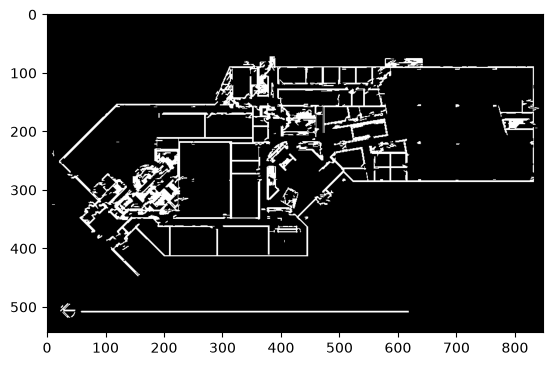

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# we'll showcase the matrix being displayed from the textfile now, first we read all of it as a matrix
matrix = []
with open('line_img_matrix.txt', 'r') as f:
    for line in f:
        matrix.append([int(x) for x in line.split()])

matrix = np.array(matrix)
print(matrix.shape)

plt.imshow(matrix, cmap='gray')
plt.show()
